# ADCP Raw Data Processing

In [289]:
from mhkit import dolfyn
from mhkit.dolfyn.adp import api
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import my_functions as my

In [168]:
ds = dolfyn.read("A0524000.000")
ds


Reading file A0524000.000 ...


<xarray.Dataset> Size: 13MB
Dimensions:              (time: 16864, range: 24, beam: 4, dir: 4, x1: 4,
                          x2: 4, earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 135kB 2024-05-13T12:00:00 ... ...
  * range                (range) float32 96B 2.12 3.12 4.12 ... 24.12 25.12
  * beam                 (beam) int32 16B 1 2 3 4
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * x1                   (x1) int64 32B 1 2 3 4
  * x2                   (x2) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) uint32 67kB 1 2 3 4 ... 16861 16862 16863 16864
    builtin_test_fail    (time) bool 17kB False False False ... False False
    c_sound              (time) float32 67kB 1.534e+03 1.534e+03 ... 1.518e+03
    depth                (time) float32 67kB 0.0 0.0 0.0 0.0 ... 22.3 22.4 22.5
    pitch                (time) float32 67kB -4.2 -4.22 -4.2 ... -6.7 -6.7 -6.68
    roll                 (time) float32 67kB -0.07 -0.04 -0.04 ... -1.28 -1.28
    ...                   ...
    vel                  (dir, range, time) float32 6MB 0.017 nan ... nan nan
    amp                  (beam, range, time) uint8 2MB 55 55 55 ... 119 122 118
    corr                 (beam, range, time) uint8 2MB 70 73 70 ... 108 104 105
    prcnt_gd             (beam, range, time) uint8 2MB 5 0 0 2 0 0 ... 0 0 0 0 0
    beam2inst_orientmat  (x1, x2) float32 64B 1.462 -1.462 0.0 ... -1.034 -1.034
    orientmat            (earth, inst, time) float32 607kB -0.7555 ... -0.993
Attributes: (12/38)
    firmware_ver:             50.4
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              ['vel']
    has_imu:                  0
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.25
    bandwidth:                0
    power_level:              255
    serialnum:                21788
    range_offset:             0.24
    fs:                       0.0011363636363636363

### Removing data before deployment

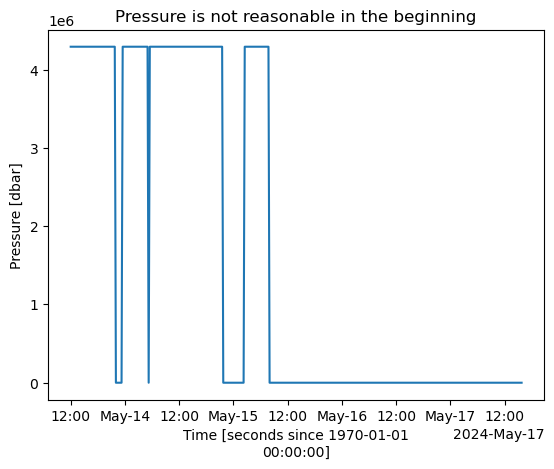

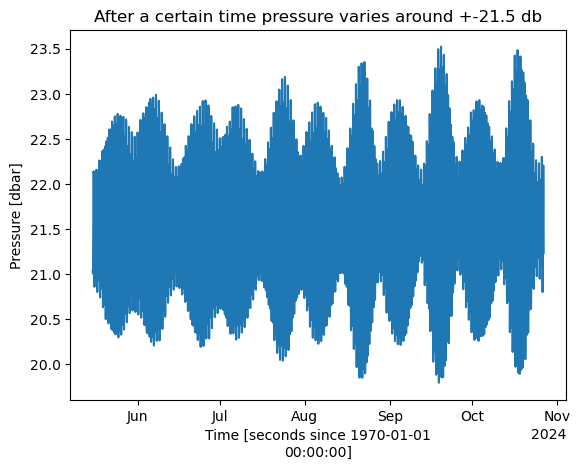

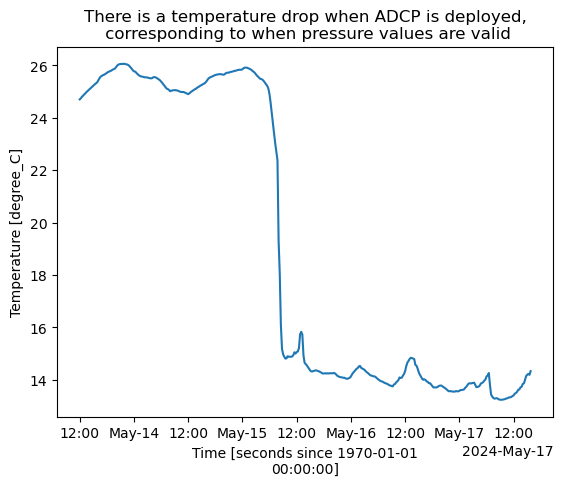

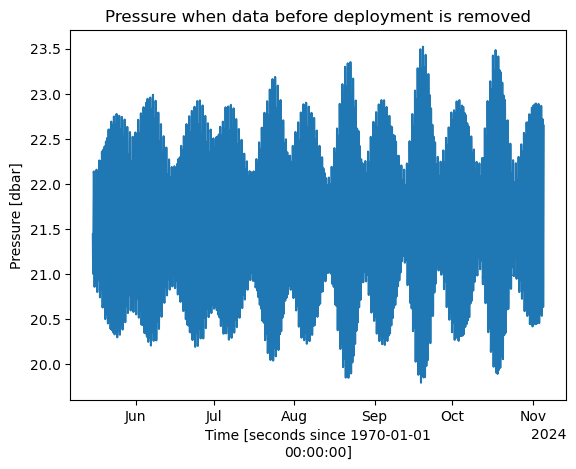

In [ ]:

ds.pressure.isel(time=slice(0, 400)).plot()
plt.title('Pressure is not reasonable in the beginning')
plt.show()

ds.pressure.isel(time=slice(200,16000)).plot()
plt.title('After a certain time, pressure varies around +-21.5 db')
plt.show()

ds.temp.isel(time=slice(0, 400)).plot()
plt.title('There is a temperature drop when ADCP is deployed,\n corresponding to when pressure values are valid')
plt.show()

deployment_time = np.datetime64("2024-05-15T12:00:00") #read off from temperature plot

ds_1 = ds.sel(time=slice(deployment_time, None))

ds_1.pressure.plot()
plt.title('Pressure when data before deployment is removed')
plt.show()


### Controlling that bin heights are correct and surface elevation accounted for

Range offset: 0.24
Blank distance: 0.88
Cell size: 1.0
Range values: [ 2.12  3.12  4.12  5.12  6.12  7.12  8.12  9.12 10.12 11.12 12.12 13.12
 14.12 15.12 16.12 17.12 18.12 19.12 20.12 21.12 22.12 23.12 24.12 25.12]


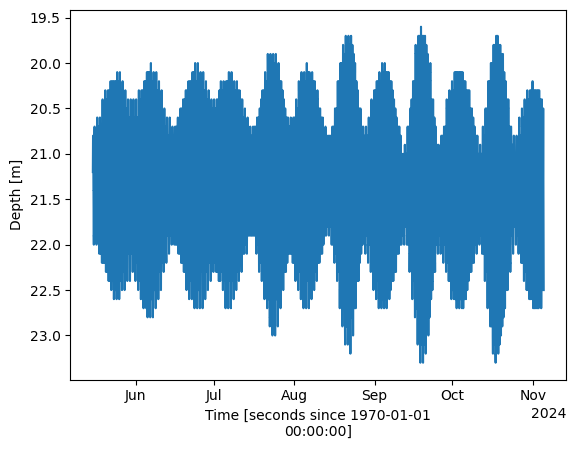

In [170]:
#0 already corresponds to seafloor
#center of first bin corresponds to range_offset + blank_dist + cell_size

print(f"Range offset: {ds_1.attrs.get('range_offset'):.2f}")
print(f"Blank distance: {ds_1.attrs.get('blank_dist')}")
print(f"Cell size: {ds_1.attrs.get('cell_size')}")
print(f"Range values: {ds_1['range'].values}")


#surface elevation accounted for, depth varies
ds_1.depth.plot()
plt.gca().invert_yaxis()
plt.show()


### Removing surface interference

Interference from reflection from the surface gives high signals, is removed based on beam angle.

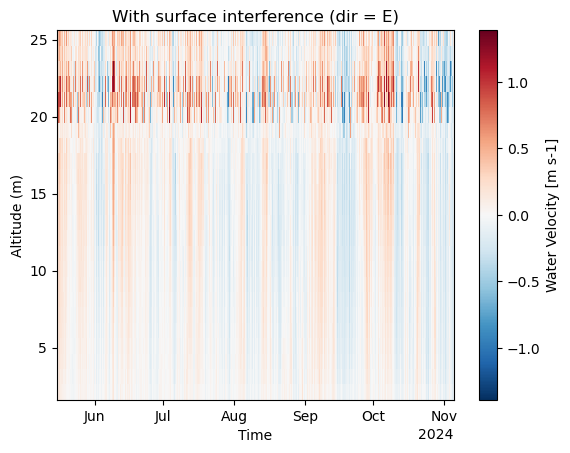

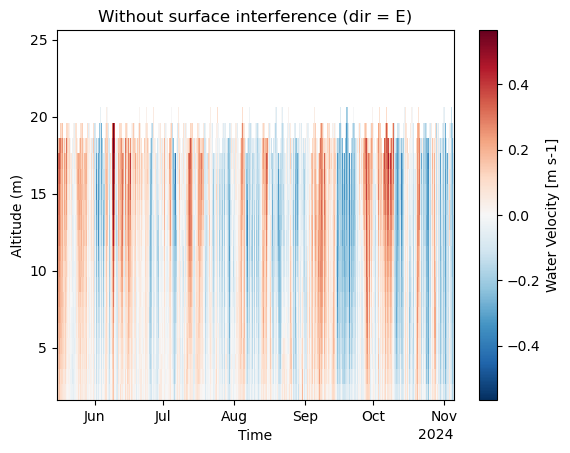

In [ ]:
ds_1["vel"][0].plot() 
plt.title("With surface interference (dir = E)")
plt.xlabel('Time')
plt.ylabel('Altitude (m)')
plt.show()

ds_2 = api.clean.remove_surface_interference(ds_1) 
ds_2["vel"][0].plot()
plt.title("Without surface interference (dir = E)")
plt.xlabel('Time')
plt.ylabel('Altitude (m)')
plt.show()


### Applying correlation filter

Correlation tells how reliable the signal in a bin is based on comparing it to the expected pattern.

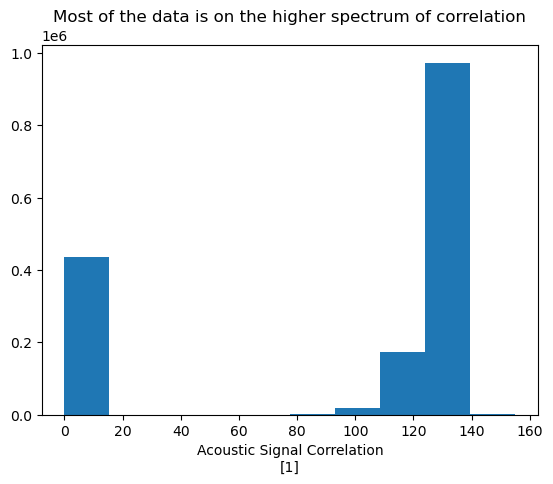

Data removed: 30636 (2.63%)


In [293]:
ds_2.corr.plot()
plt.title('Most of the data is on the higher spectrum of correlation')
plt.show()

corr_thresh=100
ds_3 = api.clean.correlation_filter(ds_2, thresh=corr_thresh) 

my.print_data_removed(ds_2, ds_3)

### Checking if data is averaged

In [196]:
#Data is already averaged, time step large
print(f"Time step: {ds_3.time.diff('time').median().values}")


Time step: 900000000000 nanoseconds


### Removing outliers from signal amplitude

The signal amplitude is strong in the beginning and then decreases. Along the beam, there should only be values lower than those in the beginning, otherwise there is interference from e.g. fish, diver etc.


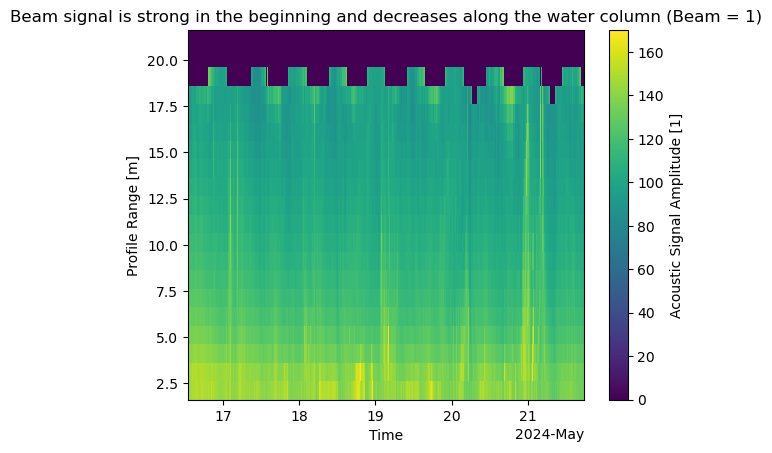

Max signals for each beam at the start [218, 212, 217, 222] 
Median signals for each beam at the end [85.0, 86.0, 75.0, 89.0] 
Data removed: 1668 (0.15%)


In [294]:
ds_3.amp[0].isel(range=slice(0,20),time=slice(100,600)).plot()
plt.xlabel('Time')
plt.title('Beam signal is strong in the beginning and decreases along the water column (Beam = 1)')
plt.show()


#finding max values of the signal in the beginning to decide bottom threshold
max_signals =[]
for i in(0,1,2,3):
     max_signals.append(ds_3.amp[i].sel(range=slice(2.12,4.12)).max().item())
print(f'Max signals for each beam at the start {max_signals} ')

#finding median values of the signal in the end to decide surface threshold
median_signals =[]
for i in(0,1,2,3):
     median_signals.append(ds_3.amp[i].sel(range=slice(18,20)).median().item())
print(f'Median signals for each beam at the end {median_signals} ')

ds_4 = my.remove_outliers(ds_3, bottom_threshold=225, surface_threshold=100)
print_data_removed(ds_3, ds_4)

###  Controlling coordinate system and setting declination

In [267]:
#earth coordinate system is already used
print(f"Coordinate system: {ds.attrs['coord_sys']}")

#need to set declination
print(f"Declination: {ds.attrs.get('declination', 'Not set')}")

dolfyn.set_declination(ds_4, -0.90) #I assumed lat=37N, long=8W, May 2024 which gave declination=0.9W. Quite low, could be neglied in this case
print(f"Declination: {ds_4.attrs.get('declination', 'Not set')}")



Coordinate system: earth
Declination: Not set
Declination: -0.9


### Filtering out interal waves (?) and tides

I want to
- convert from time domain to frequency domain
- filter out certain frequencies, semi-diurnal tidal range is about 2-2.5 Hz
do I then need to make my own filter, e.g. with scipy, or is there any easier way?


###  Saving data

In [9]:
dolfyn.save(ds_3, 'ADCP_processed_0524.nc')